In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [27]:
file = 'soybean_2021'  # or 'corn'
df = pd.read_csv(f'predictions/{file}.csv')
df = df[df['YieldGT'] > 0]  

In [28]:
crop = '' # Specify crop type: 'corn' or 'soybean' or leave empty for all
# Aggregate values by unique Filename (taking mean of predictions and ground truth)
df_agg = df.groupby('Filename').agg({
    'YieldGT': 'mean',
    'Prediction': 'mean'
}).reset_index()

if crop.lower() == 'corn':
    df_agg = df_agg[df_agg['Filename'].str.lower().str.contains('corn')]  # Filter for corn data only
elif crop.lower() == 'soybean':
    df_agg = df_agg[df_agg['Filename'].str.lower().str.contains('soybean')]  # Filter for soybean data only

print(f"Original records: {len(df_agg)}")
print(f"Unique files after aggregation: {len(df_agg)}")
df_agg.head()

Original records: 60
Unique files after aggregation: 60


,Filename,YieldGT,Prediction
0,ST2021IANE002_Soybean,0.247421,0.352314
1,ST2021IANE003_Soybean,0.458828,0.345768
2,ST2021IANE005_Soybean,0.492524,0.409044
3,ST2021IANE006_Soybean,0.476694,0.374735
4,ST2021IANE007_Soybean,0.515995,0.424923


In [29]:
# Calculate metrics on aggregated data
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate MAE
mae = mean_absolute_error(df_agg['YieldGT'], df_agg['Prediction'])

# Calculate MAPE
mape = np.mean(np.abs((df_agg['YieldGT'] - df_agg['Prediction']) / df_agg['YieldGT'])) * 100

# Calculate R-square
r2 = r2_score(df_agg['YieldGT'], df_agg['Prediction'])

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Mean Absolute Error (MAE): 0.0820
Mean Absolute Percentage Error (MAPE): 20.25%
R-squared (R²): -0.2103


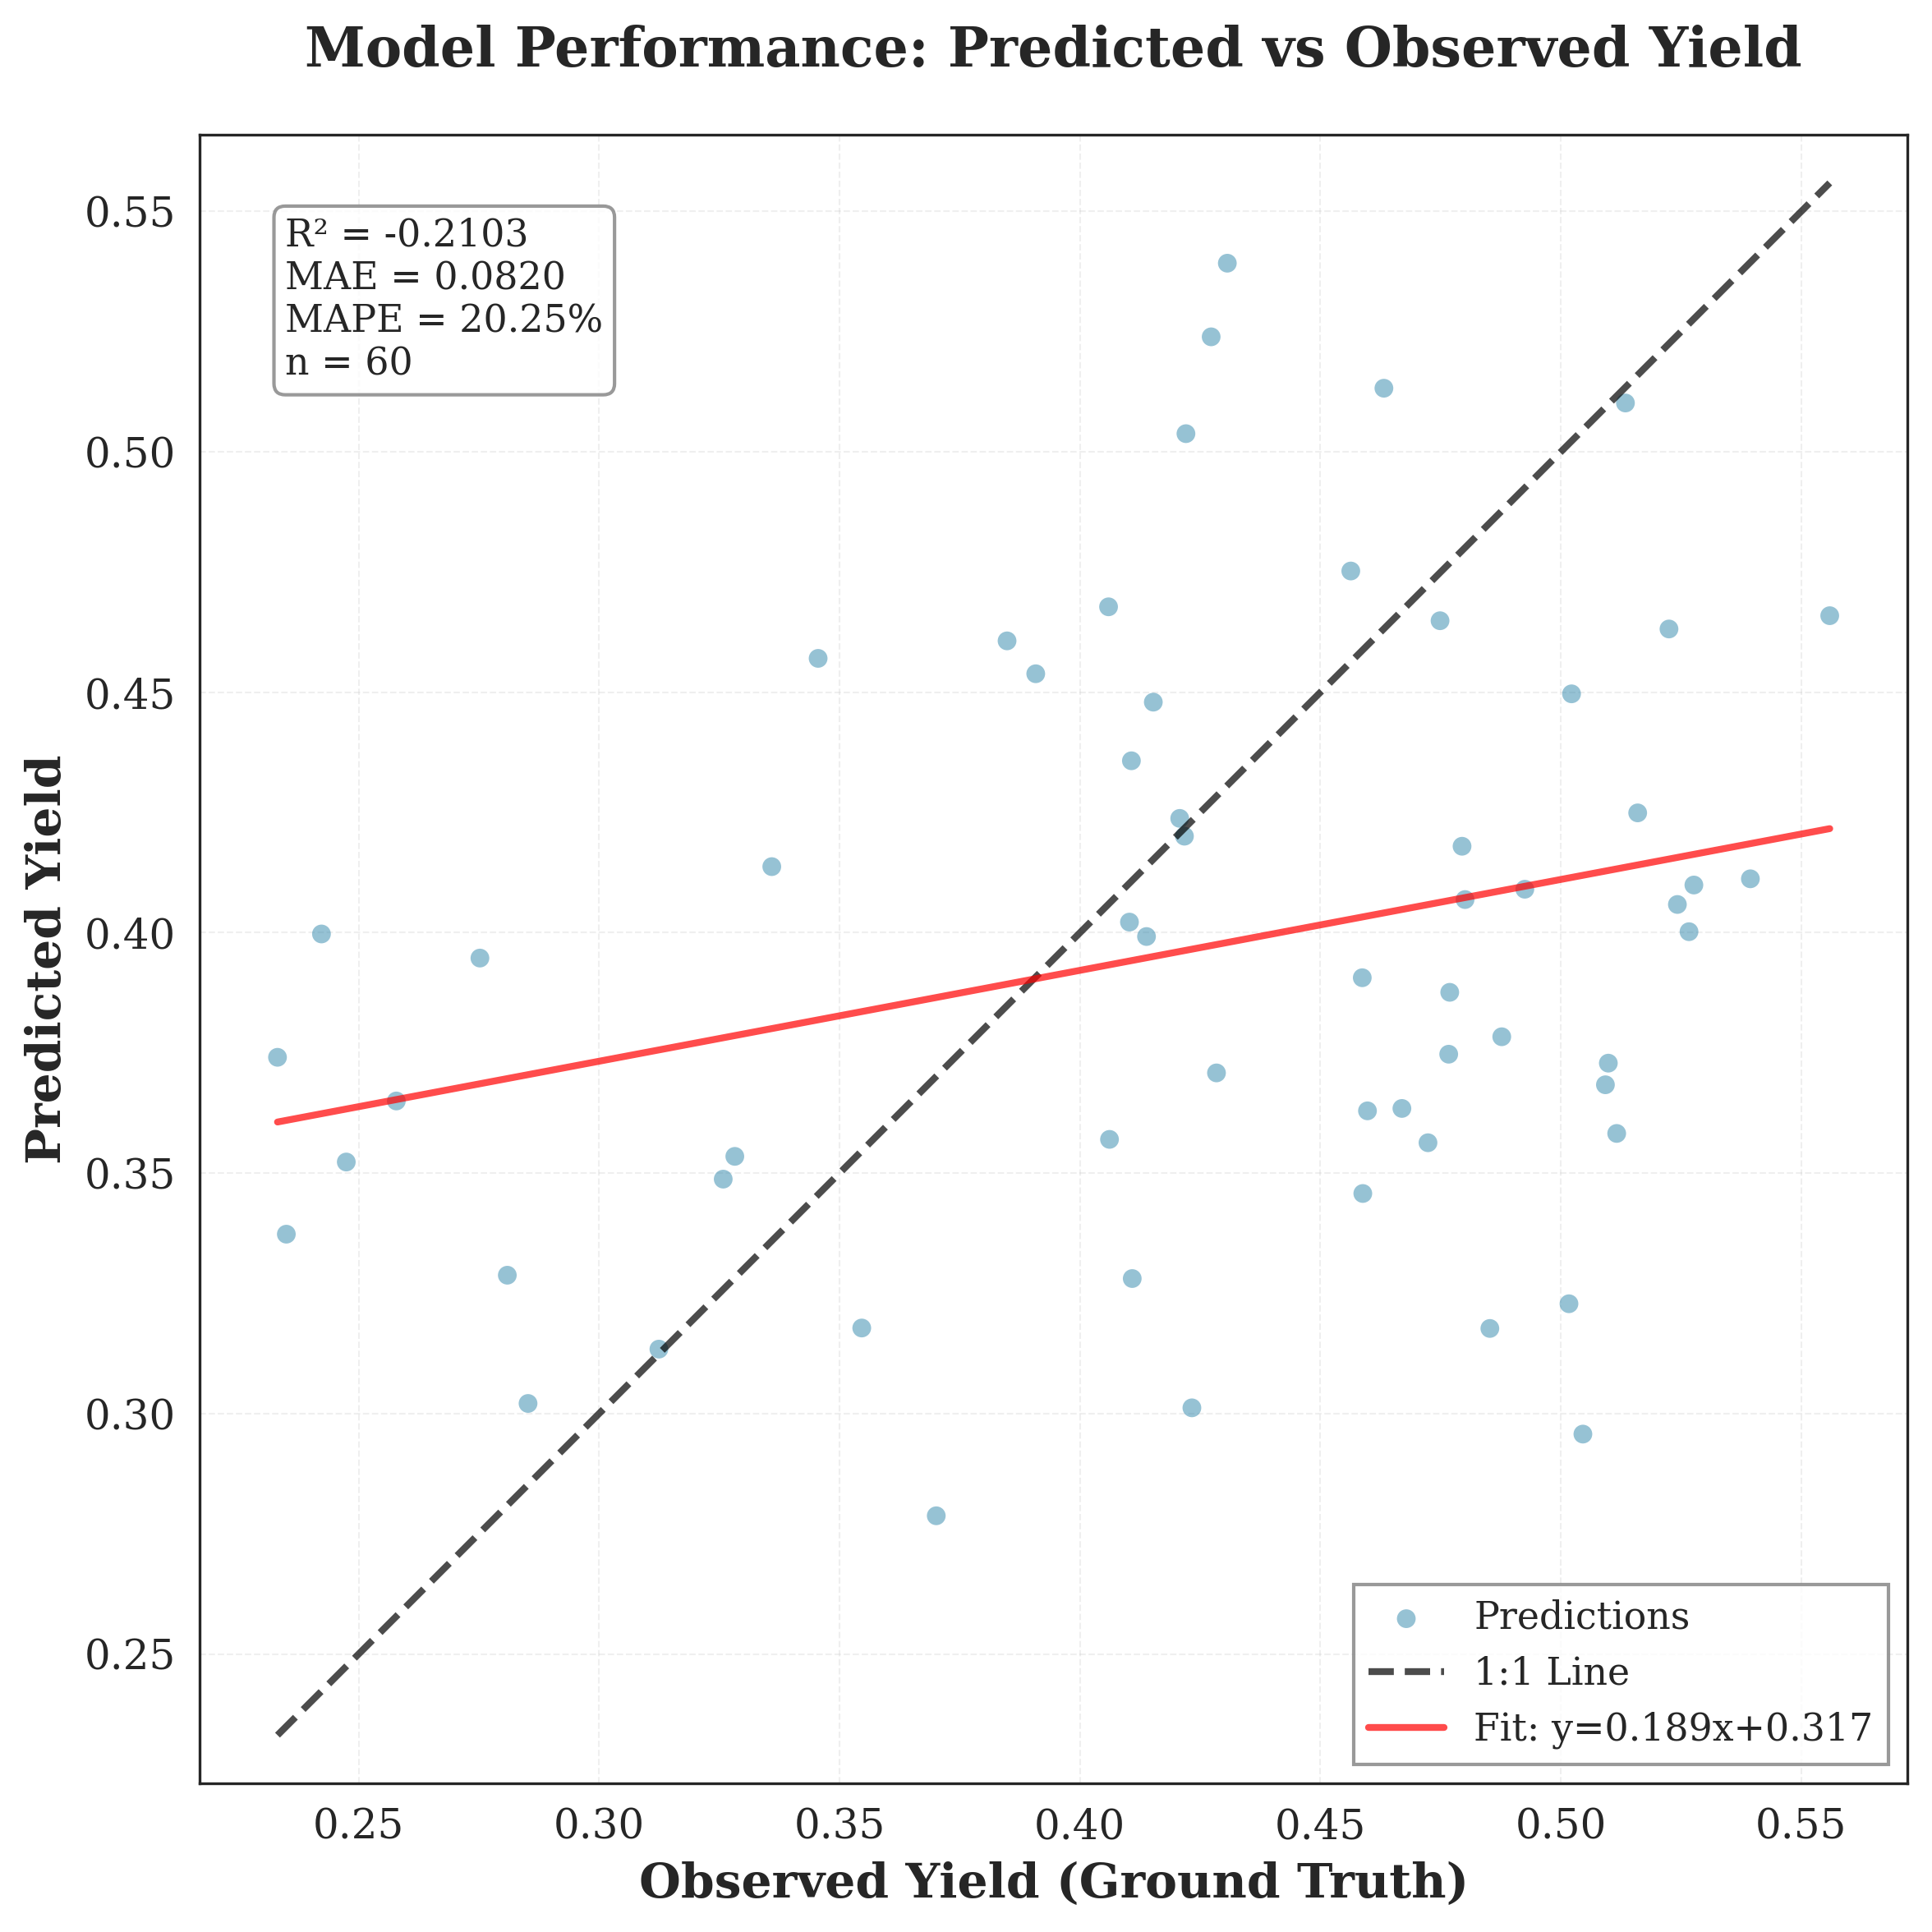


Plots saved to 'figures/r_square_plot_soybean_2021.png' and 'figures/r_square_plot_soybean_2021.pdf'


In [30]:
# Create publication-quality R-square plot
plt.figure(figsize=(8, 8), dpi=300)

# Set style for publication
sns.set_style("white")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

# Create scatter plot
plt.scatter(df_agg['YieldGT'], df_agg['Prediction'], alpha=0.5, s=30, 
            c='#2E86AB', edgecolors='none', label='Predictions')

# Add 1:1 line
min_val = min(df_agg['YieldGT'].min(), df_agg['Prediction'].min())
max_val = max(df_agg['YieldGT'].max(), df_agg['Prediction'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, 
         label='1:1 Line', alpha=0.7)

# Add regression line
z = np.polyfit(df_agg['YieldGT'], df_agg['Prediction'], 1)
p = np.poly1d(z)
plt.plot(df_agg['YieldGT'].sort_values(), p(df_agg['YieldGT'].sort_values()), 
         'r-', linewidth=2, label=f'Fit: y={z[0]:.3f}x+{z[1]:.3f}', alpha=0.7)

# Add metrics text box
textstr = f'R² = {r2:.4f}\nMAE = {mae:.4f}\nMAPE = {mape:.2f}%\nn = {len(df_agg)}'
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=props)

# Labels and formatting
plt.xlabel('Observed Yield (Ground Truth)', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Yield', fontsize=14, fontweight='bold')
plt.title('Model Performance: Predicted vs Observed Yield', fontsize=16, 
          fontweight='bold', pad=20)
plt.xlim(0,0.7)
plt.ylim(0,0.7)
# Legend
plt.legend(loc='lower right', frameon=True, fontsize=11, 
          edgecolor='gray', fancybox=False)

# Grid
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Equal aspect ratio
plt.axis('equal')
plt.tight_layout()

# Save figure
plt.savefig(f'figures/r_square_plot_{file}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'figures/r_square_plot_{file}.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlots saved to 'figures/r_square_plot_{file}.png' and 'figures/r_square_plot_{file}.pdf'")